<a href="https://colab.research.google.com/github/mahidi07/badminton-pose-analysis/blob/main/03_graph_construction_and_lstm_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03 - Graph Construction and LSTM Baseline
**Project:** Automated Pose-Based Analysis of Badminton Player Movements Using Deep Learning  
**Student:** Mahidi Ilangarathna (14486346)  
**Supervisor:** A/Prof. Nabin Sharma, UTS  

---

### What this notebook does

1. Connects to ClearML for experiment tracking
2. Loads all saved keypoint arrays from Drive and assigns class labels
3. Builds a PyTorch Dataset and DataLoader with train/val/test splits
4. Defines the COCO 17-joint adjacency matrix for use in ST-GCN later
5. Trains a 2-layer LSTM baseline classifier on flattened keypoint sequences
6. Logs all metrics and hyperparameters to ClearML automatically
7. Produces accuracy, F1-score, and a confusion matrix across all 18 classes
8. Saves the trained baseline model checkpoint to Drive

### Why LSTM before ST-GCN

The LSTM baseline exists for two reasons. First, it confirms the entire data pipeline works correctly before investing time in a more complex model. If the LSTM cannot learn anything, the problem is in the data, not the architecture. Second, it sets a performance floor. ST-GCN needs to beat this baseline to justify its added complexity - that comparison goes directly into your thesis evaluation chapter.

**Before running:** Confirm Notebooks 01 and 02 have been run and .npy files exist in Drive at `14486346_Honours/data/keypoints/`.

---
## Section 1 - ClearML Credentials

Paste your ClearML credentials here. This cell needs to be run once per Colab session. Do not commit this notebook to GitHub with the keys filled in - clear them before saving.

In [ ]:
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=GA7TDAQYE9TKEA7JSN584EF15584EO
%env CLEARML_API_SECRET_KEY=XaAWr-EvkTPi21bvQFIk2xXeNGS1DUVT-mDZGTi37KkFFGsX5dfHpjWtu1FfaEqRfvg

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=GA7TDAQYE9TKEA7JSN584EF15584EO
env: CLEARML_API_SECRET_KEY=XaAWr-EvkTPi21bvQFIk2xXeNGS1DUVT-mDZGTi37KkFFGsX5dfHpjWtu1FfaEqRfvg


---
## Section 2 - Install Libraries and Check GPU

In [ ]:
!pip install clearml scikit-learn -q
print("Libraries installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.9 MB/s eta 0:00:00
Libraries installed.


In [ ]:
import torch

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    DEVICE = torch.device('cuda')
else:
    print("No GPU. Go to Runtime > Change runtime type > T4 GPU.")
    DEVICE = torch.device('cpu')

print("Device:", DEVICE)

GPU: Tesla T4
Device: cuda


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import random
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
from clearml import Task

print("All imports OK")

All imports OK


---
## Section 3 - Mount Drive and Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE          = '/content/drive/MyDrive/14486346_Honours'
KEYPOINTS_DIR = os.path.join(BASE, 'data/keypoints')
MODELS_DIR    = os.path.join(BASE, 'models')
OUTPUTS_DIR   = os.path.join(BASE, 'outputs')

for d in [MODELS_DIR, OUTPUTS_DIR]:
    os.makedirs(d, exist_ok=True)

# Hyperparameters - all defined here so ClearML can log them cleanly
HPARAMS = {
    'target_frames'  : 30,
    'num_keypoints'  : 17,
    'input_size'     : 17 * 3,       # flattened keypoints per frame: 51
    'hidden_size'    : 256,
    'num_layers'     : 2,
    'dropout'        : 0.3,
    'learning_rate'  : 1e-3,
    'batch_size'     : 32,
    'num_epochs'     : 200,
    'train_split'    : 0.70,
    'val_split'      : 0.15,
    'test_split'     : 0.15,
    'random_seed'    : 42,
    'use_weighted_sampler': True,   # handles class imbalance
}

random.seed(HPARAMS['random_seed'])
np.random.seed(HPARAMS['random_seed'])
torch.manual_seed(HPARAMS['random_seed'])

print("Config set.")
for k, v in HPARAMS.items():
    print(f"  {k:<25} {v}")

Config set.
  target_frames             30
  num_keypoints             17
  input_size                51
  hidden_size               256
  num_layers                2
  dropout                   0.3
  learning_rate             0.001
  batch_size                32
  num_epochs                200
  train_split               0.7
  val_split                 0.15
  test_split                0.15
  random_seed               42
  use_weighted_sampler      True


---
## Section 4 - Initialise ClearML Task

This creates a new experiment in your ClearML dashboard. Every metric logged after this point appears there automatically. The task name includes key hyperparameters so runs are easy to identify when you have many of them.

In [ ]:
task = Task.init(
    project_name = 'BadmintonPoseAnalysis',
    task_name    = f'LSTM-baseline-h{HPARAMS["hidden_size"]}-lr{HPARAMS["learning_rate"]}-e{HPARAMS["num_epochs"]}',
    tags         = ['baseline', 'lstm', 'notebook-03']
)

# Log all hyperparameters to ClearML
task.connect(HPARAMS)

logger = task.get_logger()

print("ClearML task initialised.")
print("View your experiment at: https://app.clear.ml")

ClearML Task: created new task id=412ea7723ce64ef6b2aaee7f5acbb58d


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


2026-04-16 13:10:06,560 - clearml.Task - INFO - Storing jupyter notebook directly as code
ClearML results page: https://app.clear.ml/projects/89838577f7964905a3b492353933fcb2/experiments/412ea7723ce64ef6b2aaee7f5acbb58d/output/log
ClearML task initialised.
View your experiment at: https://app.clear.ml


---
## Section 5 - Load Dataset

Scans the keypoints directory, loads every .npy file, and maps class folder names to integer labels. Also prints the class distribution so you can see the imbalance immediately.

In [ ]:
npy_files = sorted(Path(KEYPOINTS_DIR).rglob('*.npy'))

if not npy_files:
    raise FileNotFoundError(f"No .npy files found in {KEYPOINTS_DIR}. Run Notebooks 01 and 02 first.")

# Build class name to index mapping from folder names
class_names = sorted(set(p.parent.name for p in npy_files))
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}
NUM_CLASSES  = len(class_names)

# Load all arrays and labels
X, y = [], []
load_errors = 0

for npy_path in npy_files:
    class_name = npy_path.parent.name
    try:
        arr = np.load(npy_path).astype(np.float32)  # (30, 17, 3)
        X.append(arr)
        y.append(class_to_idx[class_name])
    except Exception as e:
        print(f"Failed to load {npy_path.name}: {e}")
        load_errors += 1

X = np.stack(X)   # (N, 30, 17, 3)
y = np.array(y)   # (N,)

print(f"Loaded {len(X)} clips, {NUM_CLASSES} classes, {load_errors} errors.")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print()
print("Class distribution:")
counts = Counter(y)
for idx in sorted(counts):
    bar = '#' * counts[idx]
    print(f"  [{idx:>2}] {idx_to_class[idx]:<30} {counts[idx]:>4}  {bar}")

Loaded 1882 clips, 18 classes, 0 errors.
X shape: (1882, 30, 17, 3)
y shape: (1882,)

Class distribution:
  [ 0] 00_Short Serve                  100  ####################################################################################################
  [ 1] 01_Cross Court Flight           101  #####################################################################################################
  [ 2] 02_Lift                         108  ############################################################################################################
  [ 3] 03_Tap Smash                    101  #####################################################################################################
  [ 4] 04_Block                        104  ########################################################################################################
  [ 5] 05_Drop Shot                    109  #############################################################################################################
 

---
## Section 6 - Dataset Class and DataLoaders

The LSTM takes a sequence of flattened keypoint vectors. Each frame becomes a vector of 51 values (17 joints × 3 values each). The full clip becomes a sequence of shape (30, 51).

A WeightedRandomSampler is used during training to oversample underrepresented classes, which addresses the imbalance identified in the dataset (Short Serve has many more clips than Cross Court Flight, for example).

In [ ]:
class BadmintonKeypointDataset(Dataset):
    """
    Wraps keypoint arrays and labels for use with PyTorch DataLoader.

    Input array shape  : (30, 17, 3)
    Output tensor shape: (30, 51)  -- flattened per frame, ready for LSTM
    """
    def __init__(self, X, y):
        # Flatten spatial dims: (N, 30, 17, 3) -> (N, 30, 51)
        self.X = torch.tensor(
            X.reshape(X.shape[0], X.shape[1], -1), dtype=torch.float32
        )
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Train / val / test split
idx_all = np.arange(len(X))

idx_train, idx_temp = train_test_split(
    idx_all, test_size=(1 - HPARAMS['train_split']),
    stratify=y, random_state=HPARAMS['random_seed']
)
val_ratio = HPARAMS['val_split'] / (HPARAMS['val_split'] + HPARAMS['test_split'])
idx_val, idx_test = train_test_split(
    idx_temp, test_size=(1 - val_ratio),
    stratify=y[idx_temp], random_state=HPARAMS['random_seed']
)

train_dataset = BadmintonKeypointDataset(X[idx_train], y[idx_train])
val_dataset   = BadmintonKeypointDataset(X[idx_val],   y[idx_val])
test_dataset  = BadmintonKeypointDataset(X[idx_test],  y[idx_test])

print(f"Split sizes  ->  train: {len(train_dataset)}  val: {len(val_dataset)}  test: {len(test_dataset)}")

# Weighted sampler to handle class imbalance in training
if HPARAMS['use_weighted_sampler']:
    train_labels  = y[idx_train]
    class_counts  = np.bincount(train_labels, minlength=NUM_CLASSES)
    class_weights = 1.0 / np.where(class_counts == 0, 1, class_counts)
    sample_weights = class_weights[train_labels]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float32),
        num_samples=len(train_dataset),
        replacement=True
    )
    train_loader = DataLoader(train_dataset, batch_size=HPARAMS['batch_size'],
                              sampler=sampler)
    print("WeightedRandomSampler enabled for training.")
else:
    train_loader = DataLoader(train_dataset, batch_size=HPARAMS['batch_size'], shuffle=True)

val_loader  = DataLoader(val_dataset,  batch_size=HPARAMS['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=HPARAMS['batch_size'], shuffle=False)

print(f"Batch size: {HPARAMS['batch_size']}")
print(f"Input shape per batch: ({HPARAMS['batch_size']}, {HPARAMS['target_frames']}, {HPARAMS['input_size']})")

Split sizes  ->  train: 1317  val: 282  test: 283
WeightedRandomSampler enabled for training.
Batch size: 32
Input shape per batch: (32, 30, 51)


---
## Section 7 - COCO Skeleton Adjacency Matrix

Defined here for reference and future use in Notebook 04 when ST-GCN is built. The adjacency matrix encodes which joints are anatomically connected. This is the spatial graph structure that ST-GCN operates on.

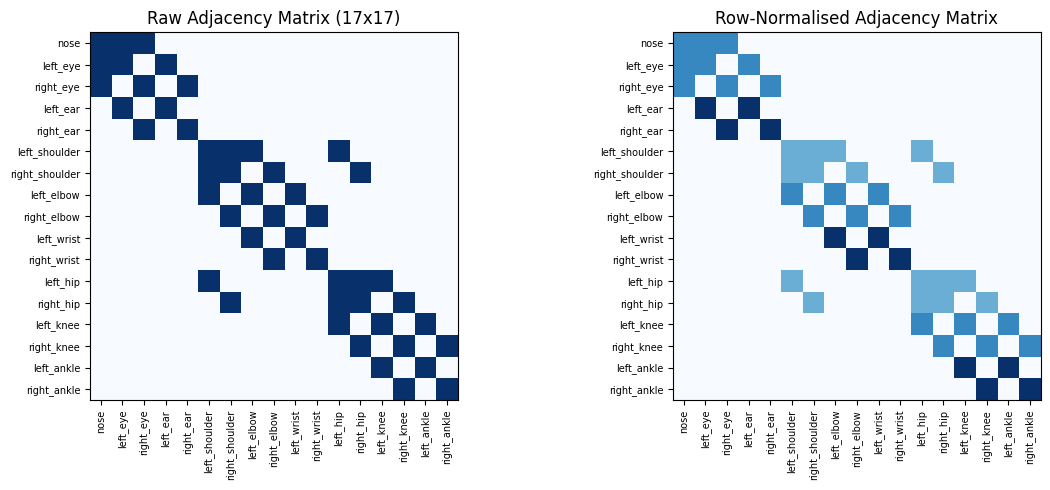

Adjacency matrix saved to: /content/drive/MyDrive/14486346_Honours/data/coco_adjacency_matrix.npy


In [ ]:
KEYPOINT_NAMES = [
    'nose','left_eye','right_eye','left_ear','right_ear',
    'left_shoulder','right_shoulder','left_elbow','right_elbow',
    'left_wrist','right_wrist','left_hip','right_hip',
    'left_knee','right_knee','left_ankle','right_ankle'
]

# COCO skeleton edges: (joint_a, joint_b)
SKELETON_EDGES = [
    (0,1),(0,2),(1,3),(2,4),           # head
    (5,6),(5,7),(7,9),(6,8),(8,10),    # arms
    (5,11),(6,12),(11,12),             # torso
    (11,13),(13,15),(12,14),(14,16)    # legs
]

# Build symmetric adjacency matrix
NUM_JOINTS = 17
A = np.zeros((NUM_JOINTS, NUM_JOINTS), dtype=np.float32)
for i, j in SKELETON_EDGES:
    A[i, j] = 1
    A[j, i] = 1
np.fill_diagonal(A, 1)  # self-connections

# Row-normalise (D^-1 * A)
row_sums = A.sum(axis=1, keepdims=True)
A_norm = A / np.where(row_sums == 0, 1, row_sums)

# Save for use in Notebook 04
adj_path = os.path.join(BASE, 'data/coco_adjacency_matrix.npy')
np.save(adj_path, A_norm)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(A, cmap='Blues')
axes[0].set_title('Raw Adjacency Matrix (17x17)')
axes[0].set_xticks(range(NUM_JOINTS))
axes[0].set_yticks(range(NUM_JOINTS))
axes[0].set_xticklabels(KEYPOINT_NAMES, rotation=90, fontsize=7)
axes[0].set_yticklabels(KEYPOINT_NAMES, fontsize=7)

axes[1].imshow(A_norm, cmap='Blues')
axes[1].set_title('Row-Normalised Adjacency Matrix')
axes[1].set_xticks(range(NUM_JOINTS))
axes[1].set_yticks(range(NUM_JOINTS))
axes[1].set_xticklabels(KEYPOINT_NAMES, rotation=90, fontsize=7)
axes[1].set_yticklabels(KEYPOINT_NAMES, fontsize=7)

plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'adjacency_matrix.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print("Adjacency matrix saved to:", adj_path)

---
## Section 8 - LSTM Baseline Model

In [ ]:
class LSTMBaseline(nn.Module):
    """
    2-layer LSTM classifier for skeleton-based action recognition.

    Input  : (batch, sequence_length, input_size)  i.e. (B, 30, 51)
    Output : (batch, num_classes)

    Uses the hidden state from the final timestep for classification.
    Dropout applied between LSTM layers and before the output head.
    """
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout):
        super(LSTMBaseline, self).__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, (hn, _) = self.lstm(x)
        # Take the last layer's final hidden state
        last_hidden = hn[-1]           # (batch, hidden_size)
        last_hidden = self.dropout(last_hidden)
        return self.classifier(last_hidden)


model = LSTMBaseline(
    input_size  = HPARAMS['input_size'],
    hidden_size = HPARAMS['hidden_size'],
    num_layers  = HPARAMS['num_layers'],
    num_classes = NUM_CLASSES,
    dropout     = HPARAMS['dropout']
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print()
print(f"Trainable parameters : {total_params:,}")
print(f"Number of classes    : {NUM_CLASSES}")
print(f"Input shape          : (batch, {HPARAMS['target_frames']}, {HPARAMS['input_size']})")

LSTMBaseline(
  (lstm): LSTM(51, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=18, bias=True)
)

Trainable parameters : 847,378
Number of classes    : 18
Input shape          : (batch, 30, 51)


---
## Section 9 - Training Loop

In [ ]:
# Class-weighted loss to further handle imbalance alongside the sampler
class_counts_all = np.bincount(y, minlength=NUM_CLASSES).astype(np.float32)
class_weights_loss = torch.tensor(
    1.0 / np.where(class_counts_all == 0, 1, class_counts_all),
    dtype=torch.float32
).to(DEVICE)
class_weights_loss = class_weights_loss / class_weights_loss.sum() * NUM_CLASSES

criterion = nn.CrossEntropyLoss(weight=class_weights_loss)
optimizer = torch.optim.Adam(model.parameters(), lr=HPARAMS['learning_rate'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print("Criterion : CrossEntropyLoss with class weights")
print("Optimiser : Adam, lr =", HPARAMS['learning_rate'])
print("Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)")

Criterion : CrossEntropyLoss with class weights
Optimiser : Adam, lr = 0.001
Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
best_model_path = os.path.join(MODELS_DIR, 'lstm_baseline_best.pt')

print(f"Training for {HPARAMS['num_epochs']} epochs...")
print("-" * 65)

for epoch in range(1, HPARAMS['num_epochs'] + 1):

    # Training
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss    += loss.item() * xb.size(0)
        train_correct += (logits.argmax(dim=1) == yb).sum().item()
        train_total   += xb.size(0)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits  = model(xb)
            loss    = criterion(logits, yb)
            val_loss    += loss.item() * xb.size(0)
            val_correct += (logits.argmax(dim=1) == yb).sum().item()
            val_total   += xb.size(0)

    t_loss = train_loss / train_total
    v_loss = val_loss   / val_total
    t_acc  = train_correct / train_total
    v_acc  = val_correct   / val_total

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    # Log to ClearML
    logger.report_scalar('Loss',     'train', t_loss, epoch)
    logger.report_scalar('Loss',     'val',   v_loss, epoch)
    logger.report_scalar('Accuracy', 'train', t_acc,  epoch)
    logger.report_scalar('Accuracy', 'val',   v_acc,  epoch)

    scheduler.step(v_loss)

    # Save best model
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save({
            'epoch'           : epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state' : optimizer.state_dict(),
            'val_loss'        : v_loss,
            'val_acc'         : v_acc,
            'hparams'         : HPARAMS,
            'class_to_idx'    : class_to_idx,
        }, best_model_path)
        saved_note = '  (saved)'
    else:
        saved_note = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{HPARAMS['num_epochs']}  "
              f"train loss: {t_loss:.4f}  acc: {t_acc:.3f}  |  "
              f"val loss: {v_loss:.4f}  acc: {v_acc:.3f}{saved_note}")

print()
print(f"Training complete. Best val loss: {best_val_loss:.4f}")
print(f"Best model saved to: {best_model_path}")

Training for 200 epochs...
-----------------------------------------------------------------
2026-04-16 13:26:50,923 - clearml.frameworks - INFO - Found existing registered model id=cd02a3485cd244c48d024e206618bf88 [/content/drive/MyDrive/14486346_Honours/models/lstm_baseline_best.pt] reusing it.
Epoch   1/200  train loss: 2.8895  acc: 0.067  |  val loss: 2.8711  acc: 0.099  (saved)
Epoch   5/200  train loss: 2.7413  acc: 0.132  |  val loss: 2.7425  acc: 0.121  (saved)
Epoch  10/200  train loss: 2.5681  acc: 0.199  |  val loss: 2.6796  acc: 0.167
Epoch  15/200  train loss: 2.4152  acc: 0.254  |  val loss: 2.8251  acc: 0.135
Epoch  20/200  train loss: 2.2051  acc: 0.317  |  val loss: 2.5744  acc: 0.206
Epoch  25/200  train loss: 2.0648  acc: 0.346  |  val loss: 2.4698  acc: 0.216
Epoch  30/200  train loss: 1.9659  acc: 0.387  |  val loss: 2.3073  acc: 0.280  (saved)
Epoch  35/200  train loss: 1.7725  acc: 0.433  |  val loss: 2.4224  acc: 0.284
Epoch  40/200  train loss: 1.5641  acc: 0.4

---
## Section 10 - Training Curves

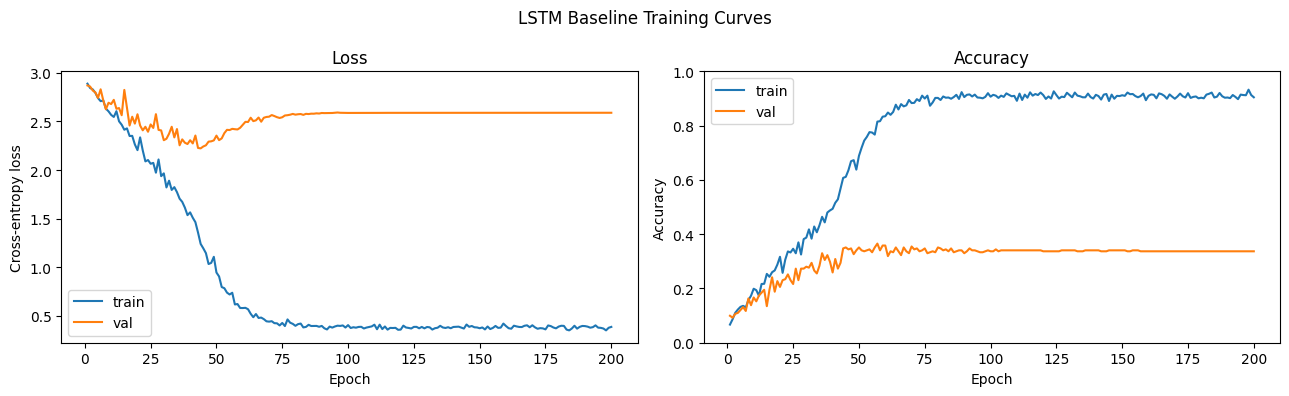

Saved to: /content/drive/MyDrive/14486346_Honours/outputs/lstm_training_curves.png


In [ ]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history['train_loss'], label='train')
axes[0].plot(epochs, history['val_loss'],   label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='train')
axes[1].plot(epochs, history['val_acc'],   label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('LSTM Baseline Training Curves', fontsize=12)
plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'lstm_training_curves.png')
plt.savefig(out, dpi=150, bbox_inches='tight')

# Log to ClearML
logger.report_image('Training curves', 'loss and accuracy', local_path=out)

plt.show()
print("Saved to:", out)

---
## Section 11 - Evaluation on Test Set

In [ ]:
# Load best checkpoint for evaluation
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} (val loss: {checkpoint['val_loss']:.4f})")

model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        preds = model(xb).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(yb.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

test_acc = accuracy_score(all_targets, all_preds)
test_f1  = f1_score(all_targets, all_preds, average='weighted', zero_division=0)

print()
print("TEST SET RESULTS")
print("-" * 40)
print(f"  Accuracy (weighted) : {test_acc:.4f}  ({test_acc*100:.1f}%)")
print(f"  F1-score (weighted) : {test_f1:.4f}")

# Log to ClearML
logger.report_scalar('Test', 'accuracy', test_acc, 0)
logger.report_scalar('Test', 'f1_score', test_f1,  0)

Loaded best model from epoch 44 (val loss: 2.2232)

TEST SET RESULTS
----------------------------------------
  Accuracy (weighted) : 0.3216  (32.2%)
  F1-score (weighted) : 0.3159


In [ ]:
# Per-class classification report
short_names = [n.replace('_', ' ') for n in class_names]
report = classification_report(
    all_targets, all_preds,
    target_names=short_names,
    zero_division=0
)
print(report)

# Save report to file
report_path = os.path.join(OUTPUTS_DIR, 'lstm_classification_report.txt')
with open(report_path, 'w') as f:
    f.write(f"LSTM Baseline Classification Report\n")
    f.write(f"Test accuracy : {test_acc:.4f}\n")
    f.write(f"Test F1       : {test_f1:.4f}\n\n")
    f.write(report)
print("Report saved to:", report_path)

                          precision    recall  f1-score   support

          00 Short Serve       0.71      0.67      0.69        15
   01 Cross Court Flight       0.18      0.13      0.15        15
                 02 Lift       0.21      0.19      0.20        16
            03 Tap Smash       0.56      0.33      0.42        15
                04 Block       0.19      0.20      0.19        15
            05 Drop Shot       0.25      0.35      0.29        17
            06 Push Shot       0.06      0.06      0.06        17
   07 Transitional Slice       0.17      0.13      0.15        15
                  08 Cut       0.23      0.38      0.29        16
            09 Rush Shot       0.56      0.60      0.58        15
      10 Defensive Clear       0.17      0.13      0.15        15
      11 Defensive Drive       0.42      0.33      0.37        15
                12 Clear       0.19      0.18      0.18        17
           13 Long Serve       0.53      0.59      0.56        17
         

---
## Section 12 - Confusion Matrix

The confusion matrix is one of the most useful outputs from this notebook. Look at which classes are being confused with each other. Clusters of confusion between similar classes (e.g. Flat Shot, Rear Court Flat Drive, Short Flat Shot) are strong evidence for class merging in your final model.

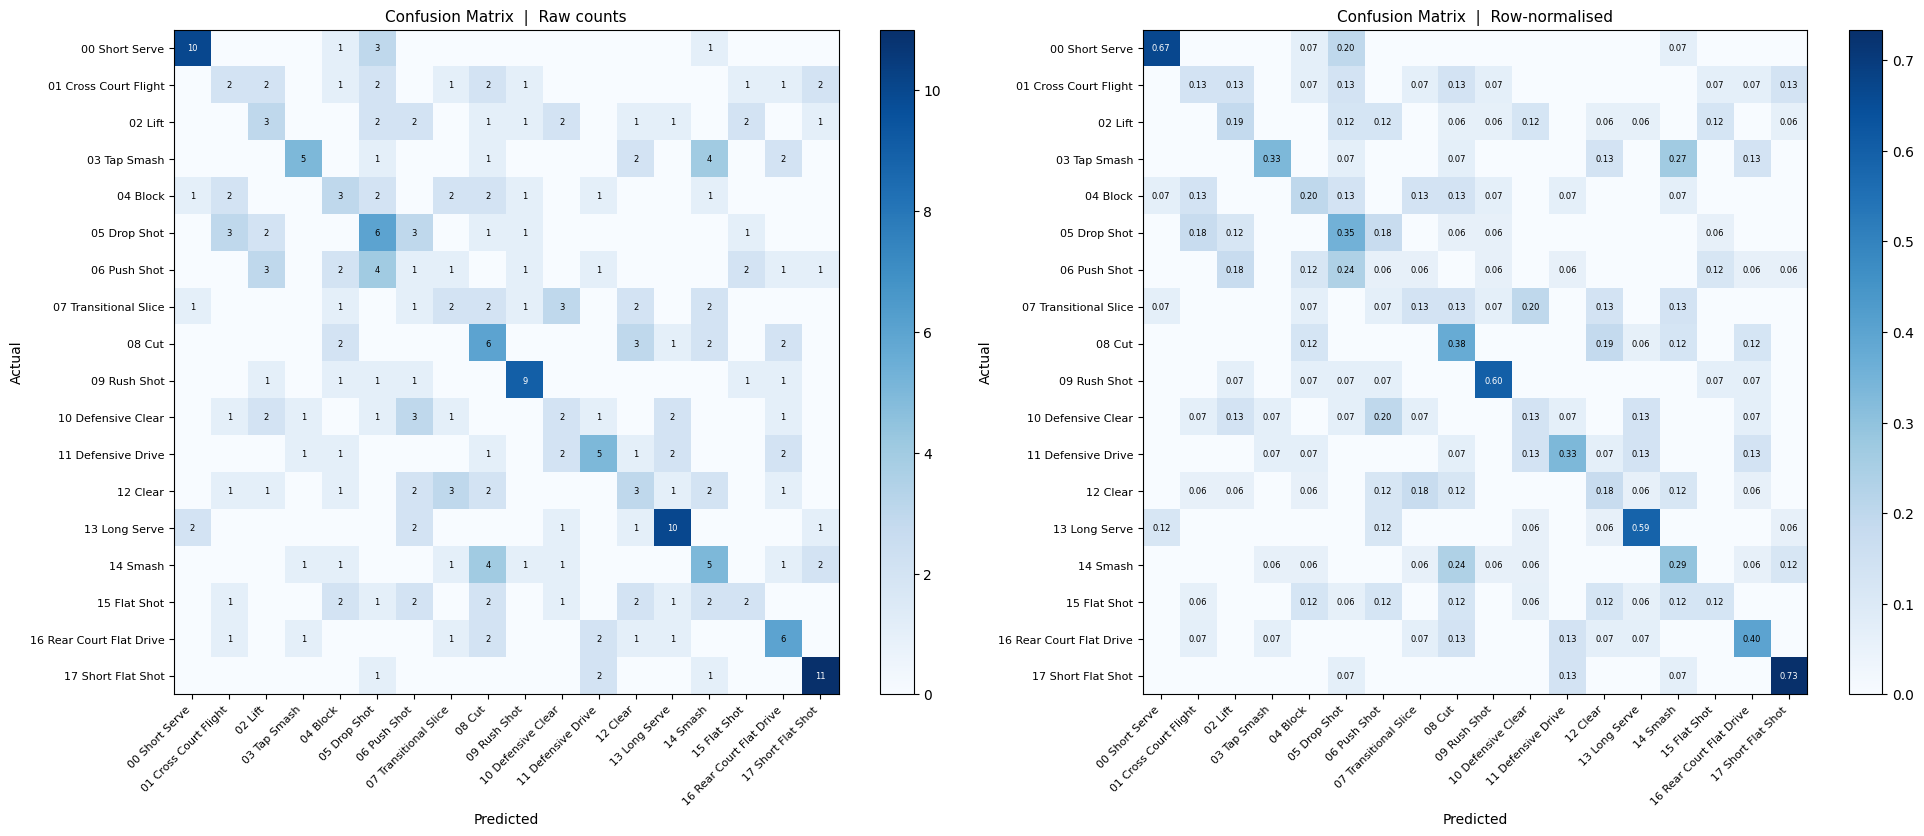

Saved to: /content/drive/MyDrive/14486346_Honours/outputs/lstm_confusion_matrix.png


In [ ]:
cm = confusion_matrix(all_targets, all_preds)

# Normalise rows to show proportions (easier to read than raw counts)
cm_norm = cm.astype(np.float32)
row_sums = cm_norm.sum(axis=1, keepdims=True)
cm_norm  = np.divide(cm_norm, row_sums, where=row_sums != 0)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, data, title, fmt in [
    (axes[0], cm,      'Raw counts',    'd'),
    (axes[1], cm_norm, 'Row-normalised', '.2f')
]:
    im = ax.imshow(data, cmap='Blues')
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix  |  {title}', fontsize=11)
    plt.colorbar(im, ax=ax)

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            val = data[i, j]
            if val > 0:
                text_color = 'white' if val > data.max() * 0.6 else 'black'
                ax.text(j, i, format(val, fmt), ha='center', va='center',
                        fontsize=6, color=text_color)

plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'lstm_confusion_matrix.png')
plt.savefig(out, dpi=150, bbox_inches='tight')

logger.report_image('Confusion matrix', 'LSTM baseline', local_path=out)

plt.show()
print("Saved to:", out)

In [ ]:
# Print the most confused class pairs - useful for deciding on class merging
print("Most confused class pairs (actual -> predicted, normalised rate):")
print("-" * 60)

confusion_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_norm[i, j] > 0.1:  # only pairs with >10% confusion
            confusion_pairs.append((cm_norm[i, j], i, j))

confusion_pairs.sort(reverse=True)

if confusion_pairs:
    for rate, i, j in confusion_pairs[:15]:
        print(f"  {idx_to_class[i]:<30}  ->  {idx_to_class[j]:<30}  {rate:.2f}")
else:
    print("  No class pairs with confusion rate above 10%.")

Most confused class pairs (actual -> predicted, normalised rate):
------------------------------------------------------------
  03_Tap Smash                    ->  14_Smash                        0.27
  14_Smash                        ->  08_Cut                          0.24
  06_Push Shot                    ->  05_Drop Shot                    0.24
  10_Defensive Clear              ->  06_Push Shot                    0.20
  07_Transitional Slice           ->  10_Defensive Clear              0.20
  00_Short Serve                  ->  05_Drop Shot                    0.20
  08_Cut                          ->  12_Clear                        0.19
  12_Clear                        ->  07_Transitional Slice           0.18
  06_Push Shot                    ->  02_Lift                         0.18
  05_Drop Shot                    ->  06_Push Shot                    0.18
  05_Drop Shot                    ->  01_Cross Court Flight           0.18
  17_Short Flat Shot              ->  11_Defensi

---
## Section 13 - Close ClearML Task and Summary

In [ ]:
# Upload model checkpoint to ClearML as an artifact
task.upload_artifact('lstm_baseline_best', artifact_object=best_model_path)

# Mark task complete
task.close()

npy_count = len(list(Path(KEYPOINTS_DIR).rglob('*.npy')))

print("NOTEBOOK 03 COMPLETE")
print("-" * 45)
print(f"  Clips used         : {len(X)}")
print(f"  Classes            : {NUM_CLASSES}")
print(f"  Test accuracy      : {test_acc*100:.1f}%")
print(f"  Test F1 (weighted) : {test_f1:.4f}")
print(f"  Best model saved   : {best_model_path}")
print(f"  ClearML project    : BadmintonPoseAnalysis")
print()
print("Things to note before the next session:")
print("  - Which classes have the lowest per-class F1 in the report above?")
print("  - Which class pairs appear most in the confusion list?")
print("  - Is the val loss curve still decreasing or has it plateaued?")
print("  - Does the gap between train and val accuracy suggest overfitting?")
print()
print("Next notebook (04):")
print("  - Build the ST-GCN model using the adjacency matrix defined here")
print("  - Train on the same data split for a direct comparison with LSTM")
print("  - ST-GCN input format: (batch, channels, frames, joints)")
print("  - Evaluate and compare against this LSTM baseline")

NOTEBOOK 03 COMPLETE
---------------------------------------------
  Clips used         : 1882
  Classes            : 18
  Test accuracy      : 32.2%
  Test F1 (weighted) : 0.3159
  Best model saved   : /content/drive/MyDrive/14486346_Honours/models/lstm_baseline_best.pt
  ClearML project    : BadmintonPoseAnalysis

Things to note before the next session:
  - Which classes have the lowest per-class F1 in the report above?
  - Which class pairs appear most in the confusion list?
  - Is the val loss curve still decreasing or has it plateaued?
  - Does the gap between train and val accuracy suggest overfitting?

Next notebook (04):
  - Build the ST-GCN model using the adjacency matrix defined here
  - Train on the same data split for a direct comparison with LSTM
  - ST-GCN input format: (batch, channels, frames, joints)
  - Evaluate and compare against this LSTM baseline
